In [32]:
!nvidia-smi
import torch, platform, os, json
print("Python:", platform.python_version())
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Mon Mar 23 18:48:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P0             50W /  400W |     562MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [33]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

assert torch.cuda.is_available(), "GPU is required. Enable GPU runtime in Colab."

device = "cuda"
torch.manual_seed(42)
np.random.seed(42)

# Same sweep for both PyTorch and cuBLAS
SIZES = [
    (256, 1024, 1024),
    (512, 1024, 2048),
    (512, 2048, 2048),
    (1024, 2048, 2048),
    (1024, 4096, 4096),
]

WARMUP = 30
ITERS = 150

def gemm_flops(B, K, N):
    return 2.0 * B * K * N

In [34]:
def bench_torch_fc(B, K, N, tf32_enabled, warmup=WARMUP, iters=ITERS):
    # Mode control
    torch.backends.cuda.matmul.allow_tf32 = tf32_enabled
    torch.backends.cudnn.allow_tf32 = tf32_enabled

    # FC-equivalent GEMM: Y = X @ W^T
    x = torch.randn(B, K, device=device, dtype=torch.float32)
    w = torch.randn(N, K, device=device, dtype=torch.float32)

    # warm-up
    for _ in range(warmup):
        _ = x @ w.t()
    torch.cuda.synchronize()

    # timed loop
    start = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)

    start.record()
    for _ in range(iters):
        _ = x @ w.t()
    end.record()
    torch.cuda.synchronize()

    total_ms = start.elapsed_time(end)
    avg_ms = total_ms / iters
    tflops = gemm_flops(B, K, N) / ((avg_ms / 1e3) * 1e12)
    return avg_ms, tflops

In [35]:
torch_rows = []
for (B, K, N) in SIZES:
    ms_fp32, tf_fp32 = bench_torch_fc(B, K, N, tf32_enabled=False)
    ms_tf32, tf_tf32 = bench_torch_fc(B, K, N, tf32_enabled=True)

    torch_rows.append({
        "B": B, "K": K, "N": N,
        "torch_fp32_no_tf32_ms": ms_fp32,
        "torch_tf32_on_ms": ms_tf32,
        "torch_fp32_no_tf32_tflops": tf_fp32,
        "torch_tf32_on_tflops": tf_tf32,
        "torch_speedup_tf32_vs_fp32": ms_fp32 / ms_tf32
    })

df_torch = pd.DataFrame(torch_rows)
df_torch.to_csv("excellent_torch_results.csv", index=False)
df_torch

,B,K,N,torch_fp32_no_tf32_ms,torch_tf32_on_ms,torch_fp32_no_tf32_tflops,torch_tf32_on_tflops,torch_speedup_tf32_vs_fp32
0,256,1024,1024,0.048401,0.025238,11.092130,21.272167,1.917771
1,512,1024,2048,0.138534,0.035383,15.501543,60.693188,3.915300
2,512,2048,2048,0.246333,0.057658,17.435584,74.490366,4.272318
3,1024,2048,2048,0.536726,0.106735,16.004315,80.479127,5.028589
4,1024,4096,4096,1.932909,0.285621,17.776179,120.298401,6.767394


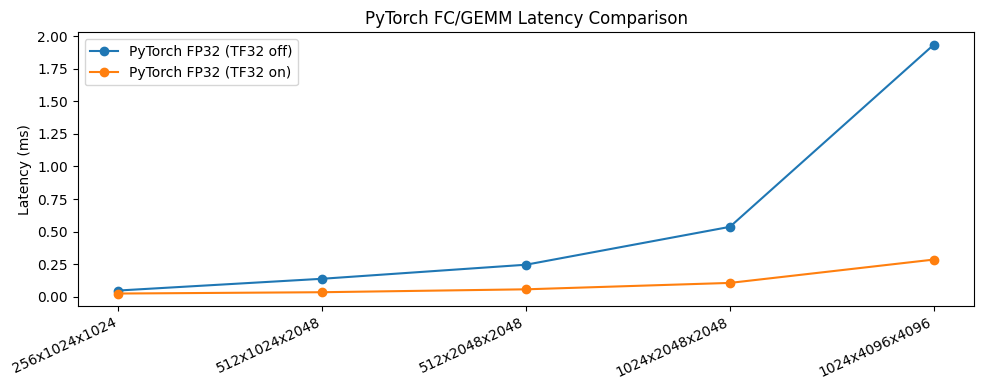

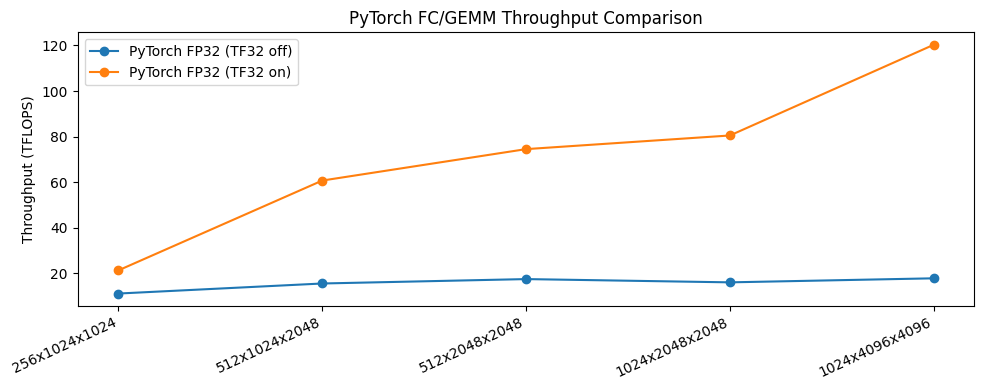

In [36]:
labels = [f"{r.B}x{r.K}x{r.N}" for r in df_torch.itertuples()]

plt.figure(figsize=(10,4))
plt.plot(labels, df_torch["torch_fp32_no_tf32_ms"], marker="o", label="PyTorch FP32 (TF32 off)")
plt.plot(labels, df_torch["torch_tf32_on_ms"], marker="o", label="PyTorch FP32 (TF32 on)")
plt.xticks(rotation=25, ha="right")
plt.ylabel("Latency (ms)")
plt.title("PyTorch FC/GEMM Latency Comparison")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(labels, df_torch["torch_fp32_no_tf32_tflops"], marker="o", label="PyTorch FP32 (TF32 off)")
plt.plot(labels, df_torch["torch_tf32_on_tflops"], marker="o", label="PyTorch FP32 (TF32 on)")
plt.xticks(rotation=25, ha="right")
plt.ylabel("Throughput (TFLOPS)")
plt.title("PyTorch FC/GEMM Throughput Comparison")
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
%%writefile gemm_bench.cu
#include <cstdio>
#include <vector>
#include <tuple>
#include <cuda_runtime.h>
#include <cublas_v2.h>

#define CHECK_CUDA(x) do { cudaError_t err = (x); if (err != cudaSuccess) { \
  printf("CUDA Error %s:%d: %s\n", __FILE__, __LINE__, cudaGetErrorString(err)); return 1; }} while(0)

#define CHECK_CUBLAS(x) do { cublasStatus_t st = (x); if (st != CUBLAS_STATUS_SUCCESS) { \
  printf("cuBLAS Error %s:%d: %d\n", __FILE__, __LINE__, (int)st); return 1; }} while(0)

double flops(int B, int K, int N) { return 2.0 * (double)B * (double)K * (double)N; }

int main() {
  std::vector<std::tuple<int,int,int>> sizes = {
    {256,1024,1024},
    {512,1024,2048},
    {512,2048,2048},
    {1024,2048,2048},
    {1024,4096,4096}
  };

  const int warmup = 30;
  const int iters  = 150;

  cublasHandle_t handle;
  CHECK_CUBLAS(cublasCreate(&handle));

  printf("B,K,N,sgemm_ms,sgemm_tflops,gemmex_ms,gemmex_tflops\n");

  for (auto &t : sizes) {
    int B = std::get<0>(t), K = std::get<1>(t), N = std::get<2>(t);

    // Row-major buffers:
    // A_rm: [B,K], B_rm: [K,N], C_rm: [B,N]
    float *A_rm, *B_rm, *C_rm;
    size_t a_bytes = (size_t)B * K * sizeof(float);
    size_t b_bytes = (size_t)K * N * sizeof(float);
    size_t c_bytes = (size_t)B * N * sizeof(float);

    CHECK_CUDA(cudaMalloc(&A_rm, a_bytes));
    CHECK_CUDA(cudaMalloc(&B_rm, b_bytes));
    CHECK_CUDA(cudaMalloc(&C_rm, c_bytes));

    CHECK_CUDA(cudaMemset(A_rm, 0, a_bytes));
    CHECK_CUDA(cudaMemset(B_rm, 0, b_bytes));
    CHECK_CUDA(cudaMemset(C_rm, 0, c_bytes));

    const float alpha = 1.0f, beta = 0.0f;

    // Row-major to column-major reinterpretation:
    // A_rm[B,K] -> A_col[K,B], lda=K
    // B_rm[K,N] -> B_col[N,K], ldb=N
    // C_rm[B,N] -> C_col[N,B], ldc=N
    // Want C_rm = A_rm * B_rm  => C_col = B_col * A_col
    int m = N, n = B, k = K;
    int ldb = N, lda = K, ldc = N;

    cudaEvent_t start, stop;
    CHECK_CUDA(cudaEventCreate(&start));
    CHECK_CUDA(cudaEventCreate(&stop));

    // Baseline: cublasSgemm (FP32)
    CHECK_CUBLAS(cublasSetMathMode(handle, CUBLAS_DEFAULT_MATH));

    for (int i = 0; i < warmup; i++) {
      CHECK_CUBLAS(cublasSgemm(
        handle,
        CUBLAS_OP_N, CUBLAS_OP_N,
        m, n, k,
        &alpha,
        B_rm, ldb,
        A_rm, lda,
        &beta,
        C_rm, ldc
      ));
    }
    CHECK_CUDA(cudaDeviceSynchronize());

    CHECK_CUDA(cudaEventRecord(start));
    for (int i = 0; i < iters; i++) {
      CHECK_CUBLAS(cublasSgemm(
        handle, CUBLAS_OP_N, CUBLAS_OP_N,
        m, n, k, &alpha, B_rm, ldb, A_rm, lda, &beta, C_rm, ldc
      ));
    }
    CHECK_CUDA(cudaEventRecord(stop));
    CHECK_CUDA(cudaEventSynchronize(stop));

    float total_sgemm_ms = 0.0f;
    CHECK_CUDA(cudaEventElapsedTime(&total_sgemm_ms, start, stop));
    float sgemm_ms = total_sgemm_ms / iters;
    float sgemm_tflops = (float)(flops(B,K,N) / ((sgemm_ms/1e3) * 1e12));

    // Tensor path: cublasGemmEx with TF32 tensor ops
    CHECK_CUBLAS(cublasSetMathMode(handle, CUBLAS_TF32_TENSOR_OP_MATH));

    for (int i = 0; i < warmup; i++) {
      CHECK_CUBLAS(cublasGemmEx(
        handle,
        CUBLAS_OP_N, CUBLAS_OP_N,
        m, n, k,
        &alpha,
        B_rm, CUDA_R_32F, ldb,
        A_rm, CUDA_R_32F, lda,
        &beta,
        C_rm, CUDA_R_32F, ldc,
        CUBLAS_COMPUTE_32F,
        CUBLAS_GEMM_DEFAULT_TENSOR_OP
      ));
    }
    CHECK_CUDA(cudaDeviceSynchronize());

    CHECK_CUDA(cudaEventRecord(start));
    for (int i = 0; i < iters; i++) {
      CHECK_CUBLAS(cublasGemmEx(
        handle,
        CUBLAS_OP_N, CUBLAS_OP_N,
        m, n, k,
        &alpha,
        B_rm, CUDA_R_32F, ldb,
        A_rm, CUDA_R_32F, lda,
        &beta,
        C_rm, CUDA_R_32F, ldc,
        CUBLAS_COMPUTE_32F,
        CUBLAS_GEMM_DEFAULT_TENSOR_OP
      ));
    }
    CHECK_CUDA(cudaEventRecord(stop));
    CHECK_CUDA(cudaEventSynchronize(stop));

    float total_gemmex_ms = 0.0f;
    CHECK_CUDA(cudaEventElapsedTime(&total_gemmex_ms, start, stop));
    float gemmex_ms = total_gemmex_ms / iters;
    float gemmex_tflops = (float)(flops(B,K,N) / ((gemmex_ms/1e3) * 1e12));

    printf("%d,%d,%d,%.6f,%.6f,%.6f,%.6f\n",
           B, K, N, sgemm_ms, sgemm_tflops, gemmex_ms, gemmex_tflops);

    cudaEventDestroy(start);
    cudaEventDestroy(stop);
    cudaFree(A_rm);
    cudaFree(B_rm);
    cudaFree(C_rm);
  }

  cublasDestroy(handle);
  return 0;
}

Overwriting gemm_bench.cu


In [38]:
!nvcc -O3 gemm_bench.cu -lcublas -o gemm_bench
!./gemm_bench > excellent_cublas_results.csv
!cat excellent_cublas_results.csv

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
B,K,N,sgemm_ms,sgemm_tflops,gemmex_ms,gemmex_tflops
256,1024,1024,0.050353,10.662039,0.020507,26.179493
512,1024,2048,0.136984,15.676906,0.034475,62.291641
512,2048,2048,0.256703,16.731262,0.059747,71.885925
1024,2048,2048,0.480358,17.882345,0.094543,90.857903
1024,4096,4096,1.844163,18.631620,0.307494,111.741333


In [39]:
import pandas as pd

# Read cuBLAS CSV robustly
df_cublas = pd.read_csv("excellent_cublas_results.csv")

# Clean possible whitespace in column names
df_cublas.columns = [c.strip() for c in df_cublas.columns]

# Force numeric for join keys and metrics
for col in ["B", "K", "N", "sgemm_ms", "sgemm_tflops", "gemmex_ms", "gemmex_tflops"]:
    df_cublas[col] = pd.to_numeric(df_cublas[col], errors="coerce")

# Drop bad rows (if any accidental text line exists)
df_cublas = df_cublas.dropna(subset=["B", "K", "N"]).copy()

# Convert keys to int
df_cublas[["B", "K", "N"]] = df_cublas[["B", "K", "N"]].astype(int)
df_torch[["B", "K", "N"]] = df_torch[["B", "K", "N"]].astype(int)

# Merge
df_all = df_torch.merge(df_cublas, on=["B", "K", "N"], how="inner")

# Derived columns
df_all["cublas_speedup_gemmex_vs_sgemm"] = df_all["sgemm_ms"] / df_all["gemmex_ms"]
df_all["size"] = df_all["B"].astype(str) + "x" + df_all["K"].astype(str) + "x" + df_all["N"].astype(str)

df_all.to_csv("excellent_combined_results.csv", index=False)
df_all

,B,K,N,torch_fp32_no_tf32_ms,torch_tf32_on_ms,torch_fp32_no_tf32_tflops,torch_tf32_on_tflops,torch_speedup_tf32_vs_fp32,sgemm_ms,sgemm_tflops,gemmex_ms,gemmex_tflops,cublas_speedup_gemmex_vs_sgemm,size
0,256,1024,1024,0.048401,0.025238,11.092130,21.272167,1.917771,0.050353,10.662039,0.020507,26.179493,2.455405,256x1024x1024
1,512,1024,2048,0.138534,0.035383,15.501543,60.693188,3.915300,0.136984,15.676906,0.034475,62.291641,3.973430,512x1024x2048
2,512,2048,2048,0.246333,0.057658,17.435584,74.490366,4.272318,0.256703,16.731262,0.059747,71.885925,4.296500,512x2048x2048
3,1024,2048,2048,0.536726,0.106735,16.004315,80.479127,5.028589,0.480358,17.882345,0.094543,90.857903,5.080842,1024x2048x2048
4,1024,4096,4096,1.932909,0.285621,17.776179,120.298401,6.767394,1.844163,18.631620,0.307494,111.741333,5.997395,1024x4096x4096


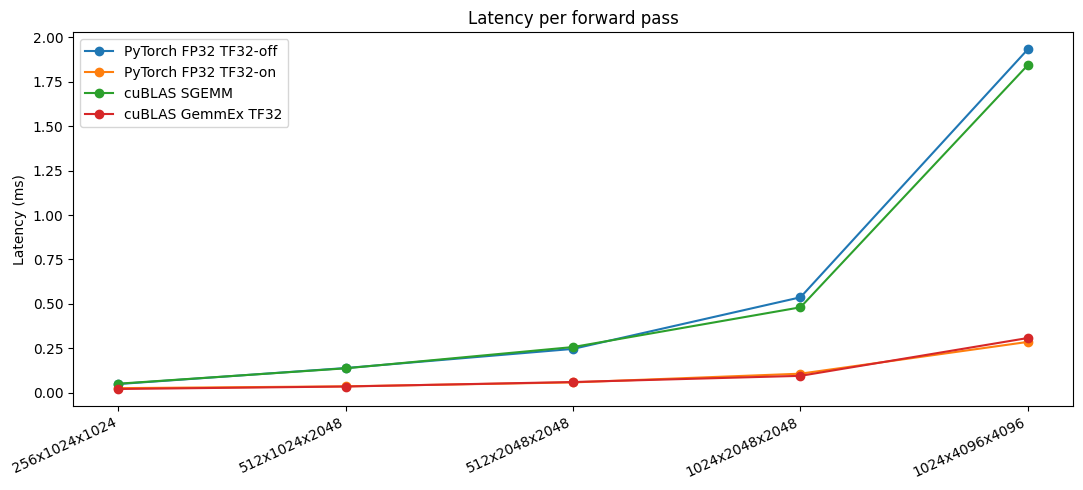

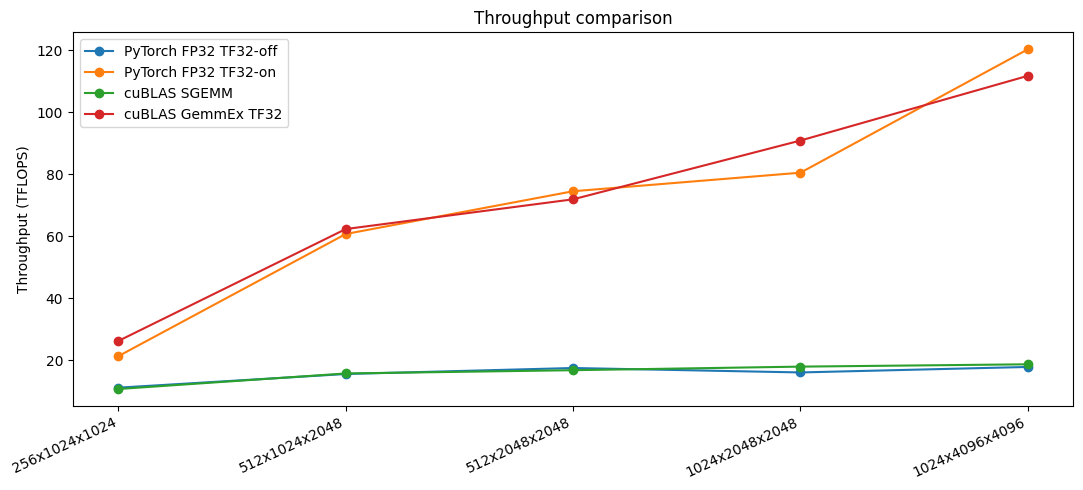

In [40]:
x = df_all["size"]

plt.figure(figsize=(11,5))
plt.plot(x, df_all["torch_fp32_no_tf32_ms"], marker="o", label="PyTorch FP32 TF32-off")
plt.plot(x, df_all["torch_tf32_on_ms"], marker="o", label="PyTorch FP32 TF32-on")
plt.plot(x, df_all["sgemm_ms"], marker="o", label="cuBLAS SGEMM")
plt.plot(x, df_all["gemmex_ms"], marker="o", label="cuBLAS GemmEx TF32")
plt.xticks(rotation=25, ha="right")
plt.ylabel("Latency (ms)")
plt.title("Latency per forward pass")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(11,5))
plt.plot(x, df_all["torch_fp32_no_tf32_tflops"], marker="o", label="PyTorch FP32 TF32-off")
plt.plot(x, df_all["torch_tf32_on_tflops"], marker="o", label="PyTorch FP32 TF32-on")
plt.plot(x, df_all["sgemm_tflops"], marker="o", label="cuBLAS SGEMM")
plt.plot(x, df_all["gemmex_tflops"], marker="o", label="cuBLAS GemmEx TF32")
plt.xticks(rotation=25, ha="right")
plt.ylabel("Throughput (TFLOPS)")
plt.title("Throughput comparison")
plt.legend()
plt.tight_layout()
plt.show()

In [41]:
gpu = torch.cuda.get_device_name(0)
print(f"""
Excellent Option Benchmark Summary

Hardware:
- GPU: {gpu}
- PyTorch: {torch.__version__}

Modes compared (same FC/GEMM sizes):
1) CUDA-core baseline:
   - PyTorch FP32 with TF32 disabled
   - cuBLAS cublasSgemm (FP32)
2) Tensor-core path:
   - PyTorch FP32 with TF32 enabled
   - cuBLAS cublasGemmEx with TF32 tensor-op math mode (FP32 I/O, TF32 compute)

Method:
- Warmup iterations: {WARMUP}
- Timed iterations: {ITERS}
- GPU timing via CUDA events + synchronization
- Reported average latency per forward pass (ms)
- Computed throughput (TFLOPS) = 2*B*K*N / time

Deliverables generated:
- excellent_torch_results.csv
- excellent_cublas_results.csv
- excellent_combined_results.csv
- latency and throughput comparison plots
""")


Excellent Option Benchmark Summary

Hardware:
- GPU: NVIDIA A100-SXM4-40GB
- PyTorch: 2.10.0+cu128

Modes compared (same FC/GEMM sizes):
1) CUDA-core baseline:
   - PyTorch FP32 with TF32 disabled
   - cuBLAS cublasSgemm (FP32)
2) Tensor-core path:
   - PyTorch FP32 with TF32 enabled
   - cuBLAS cublasGemmEx with TF32 tensor-op math mode (FP32 I/O, TF32 compute)

Method:
- Warmup iterations: 30
- Timed iterations: 150
- GPU timing via CUDA events + synchronization
- Reported average latency per forward pass (ms)
- Computed throughput (TFLOPS) = 2*B*K*N / time

Deliverables generated:
- excellent_torch_results.csv
- excellent_cublas_results.csv
- excellent_combined_results.csv
- latency and throughput comparison plots

